In [26]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from scipy.io import loadmat
import matplotlib.pyplot as plt

In [ ]:
class ShanghaiCrowdDatasetTF:
    def __init__(self, image_dir, gt_dir, img_size=(224, 224), scale_factor=100.0):
        self.image_dir = image_dir
        self.gt_dir = gt_dir
        self.img_size = img_size
        self.scale_factor = scale_factor
        self.image_files = sorted(os.listdir(image_dir))
        self.gt_files = sorted(os.listdir(gt_dir))

    def create_gaussian_kernel(self, kernel_size=25, sigma=6.0):
        ax = np.linspace(-(kernel_size // 2), kernel_size // 2, kernel_size)
        xx, yy = np.meshgrid(ax, ax)
        kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
        return kernel / np.sum(kernel)

    def generate_density_map(self, img_shape, coordinates):
        density_map = np.zeros(img_shape[:2], dtype=np.float32)
        kernel_size = 25
        sigma = 6.0
        gaussian_kernel = self.create_gaussian_kernel(kernel_size, sigma)
        half_k = kernel_size // 2

        for coord in coordinates:
            x, y = int(coord[0]), int(coord[1])
            x_min = max(x - half_k, 0)
            y_min = max(y - half_k, 0)
            x_max = min(x + half_k + 1, img_shape[1])
            y_max = min(y + half_k + 1, img_shape[0])

            img_w = x_max - x_min
            img_h = y_max - y_min

            if img_w <= 0 or img_h <= 0:
                continue

            g_x_min = half_k - (x - x_min)
            g_y_min = half_k - (y - y_min)
            g_x_max = g_x_min + img_w
            g_y_max = g_y_min + img_h

            if (g_y_max - g_y_min) != img_h or (g_x_max - g_x_min) != img_w:
                continue

            density_map[y_min:y_max, x_min:x_max] += gaussian_kernel[g_y_min:g_y_max, g_x_min:g_x_max]

        return density_map

    def _parse_function(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        gt_path = os.path.join(self.gt_dir, self.gt_files[idx])

        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_shape = img.shape

        mat_data = loadmat(gt_path)
        coords = mat_data['image_info'][0, 0]['location'][0, 0]

        density_map = self.generate_density_map(orig_shape, coords)
        orig_sum = density_map.sum()

        img = cv2.resize(img, self.img_size)
        density_map = cv2.resize(density_map, self.img_size)

        if density_map.sum() > 0:
            density_map = density_map * (orig_sum / (density_map.sum() + 1e-12)) * self.scale_factor

        img = img.astype(np.float32) / 255.0

        return img, density_map[..., np.newaxis]

    def generator(self):
        for i in range(len(self.image_files)):
            img, den = self._parse_function(i)
            yield img, den

    def get_dataset(self, batch_size=4, shuffle=True):
        ds = tf.data.Dataset.from_generator(
            self.generator,
            output_signature=(
                tf.TensorSpec(shape=(*self.img_size, 3), dtype=tf.float32),
                tf.TensorSpec(shape=(*self.img_size, 1), dtype=tf.float32)
            )
        )
        if shuffle:
            ds = ds.shuffle(buffer_size=100)
        ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
        return ds

In [ ]:
def build_mcnn():
    input_layer = layers.Input(shape=(224, 224, 3))

    b1 = layers.Conv2D(16, 9, padding='same', activation='relu')(input_layer)
    b1 = layers.MaxPooling2D(2)(b1)
    b1 = layers.Conv2D(32, 7, padding='same', activation='relu')(b1)
    b1 = layers.MaxPooling2D(2)(b1)
    b1 = layers.Conv2D(16, 7, padding='same', activation='relu')(b1)
    b1 = layers.Conv2D(8, 7, padding='same', activation='relu')(b1)

    b2 = layers.Conv2D(20, 7, padding='same', activation='relu')(input_layer)
    b2 = layers.MaxPooling2D(2)(b2)
    b2 = layers.Conv2D(40, 5, padding='same', activation='relu')(b2)
    b2 = layers.MaxPooling2D(2)(b2)
    b2 = layers.Conv2D(20, 5, padding='same', activation='relu')(b2)
    b2 = layers.Conv2D(10, 5, padding='same', activation='relu')(b2)

    b3 = layers.Conv2D(24, 5, padding='same', activation='relu')(input_layer)
    b3 = layers.MaxPooling2D(2)(b3)
    b3 = layers.Conv2D(48, 3, padding='same', activation='relu')(b3)
    b3 = layers.MaxPooling2D(2)(b3)
    b3 = layers.Conv2D(24, 3, padding='same', activation='relu')(b3)
    b3 = layers.Conv2D(12, 3, padding='same', activation='relu')(b3)

    concat = layers.Concatenate()([b1, b2, b3])

    fuse = layers.Conv2D(1, 1, padding='same')(concat)

    upsample = layers.UpSampling2D(size=4, interpolation='bilinear')(fuse)

    output = layers.ReLU()(upsample)

    return models.Model(inputs=input_layer, outputs=output)

In [29]:
def plot_prediction(image_tensor, gt_density, pred_density, idx=0, scale_factor=100.0):
    image = image_tensor[idx].numpy()
    gt = gt_density[idx].numpy().squeeze() / scale_factor
    pred = pred_density[idx].squeeze() / scale_factor

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gt, cmap='jet')
    plt.title(f"Ground Truth\nCount: {gt.sum():.1f}")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred, cmap='jet')
    plt.title(f"Prediction\nCount: {pred.sum():.1f}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
image_dir = 'ShanghaiTech/part_B_final/train_data/images'
gt_dir = 'ShanghaiTech/part_B_final/train_data/ground_truth'

img_size = (224, 224)
scale_factor = 100.0
batch_size = 4

dataset_builder = ShanghaiCrowdDatasetTF(image_dir, gt_dir, img_size=img_size, scale_factor=scale_factor)
train_ds = dataset_builder.get_dataset(batch_size=batch_size, shuffle=True)

In [ ]:
model = build_mcnn()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='mse')

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_mcnn_model.h5", save_best_only=True, monitor="loss", mode="min"
)

Epoch 1/50
    100/Unknown 45s 412ms/step - loss: 1.8378

/home/cse/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 413ms/step - loss: 1.8354
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - loss: 1.6134

100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 411ms/step - loss: 1.6120
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - loss: 1.6002

100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 423ms/step - loss: 1.5983
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - loss: 1.5320

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 404ms/step - loss: 1.1349
Epoch 37/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 431ms/step - loss: 1.1846
Epoch 38/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 412ms/step - loss: 1.1791
Epoch 39/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - loss: 1.2106

100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 409ms/step - loss: 1.2094
Epoch 40/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 410ms/step - loss: 1.2838
Epoch 41/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 424ms/step - loss: 1.2345
Epoch 42/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 426ms/step - loss: 1.2372
Epoch 43/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - loss: 1.1528

100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 418ms/step - loss: 1.1521
Epoch 44/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - loss: 1.2295

100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 433ms/step - loss: 1.2279
Epoch 45/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 423ms/step - loss: 1.1575
Epoch 46/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 420ms/step - loss: 1.2244
Epoch 47/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 425ms/step - loss: 1.1866
Epoch 48/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 403ms/step - loss: 1.2350
Epoch 49/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 403ms/step - loss: 1.1772
Epoch 50/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - loss: 1.1815

100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 412ms/step - loss: 1.1803
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


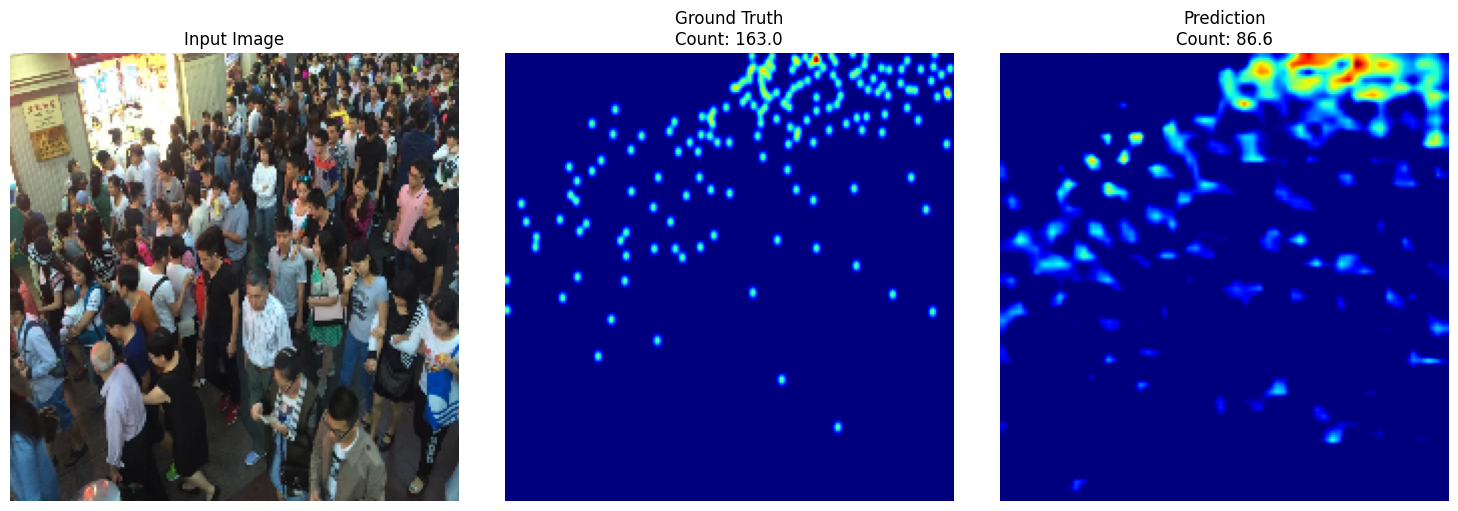

In [ ]:
model.fit(train_ds, epochs=50, callbacks=[checkpoint_cb])

model.load_weights("best_mcnn_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


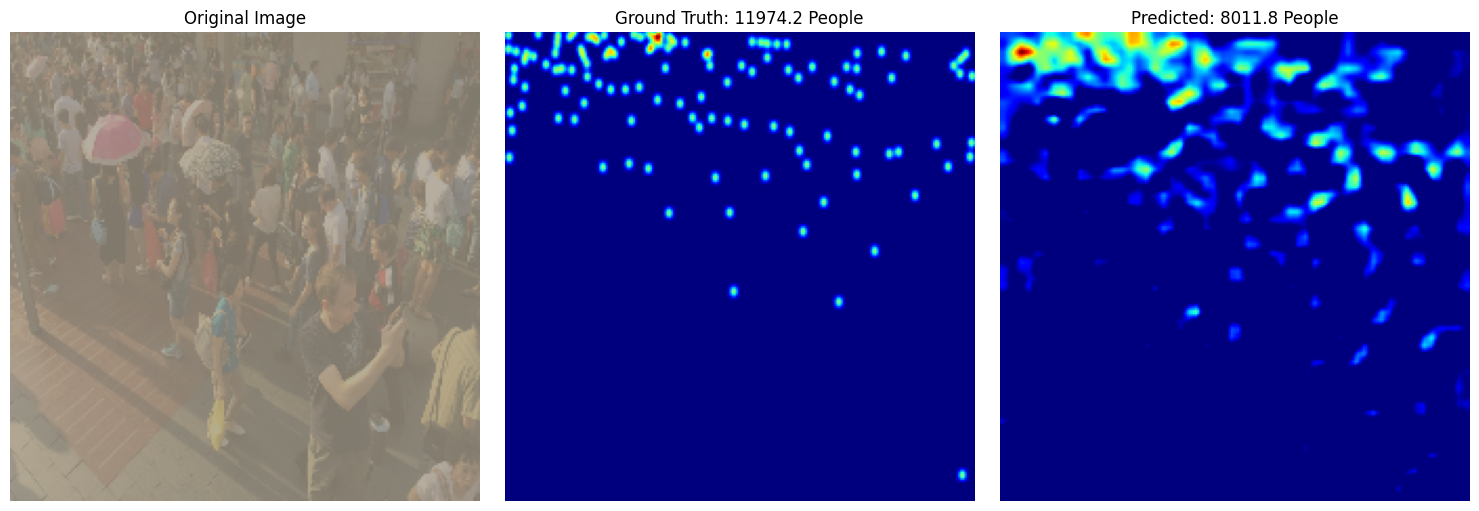

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


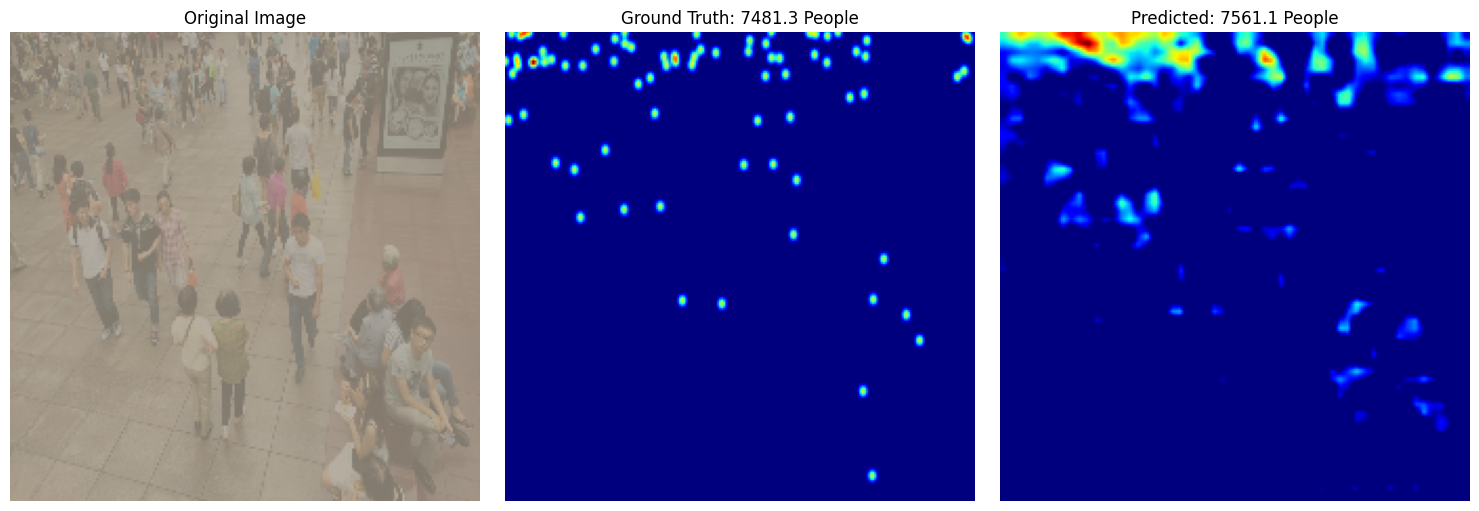

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


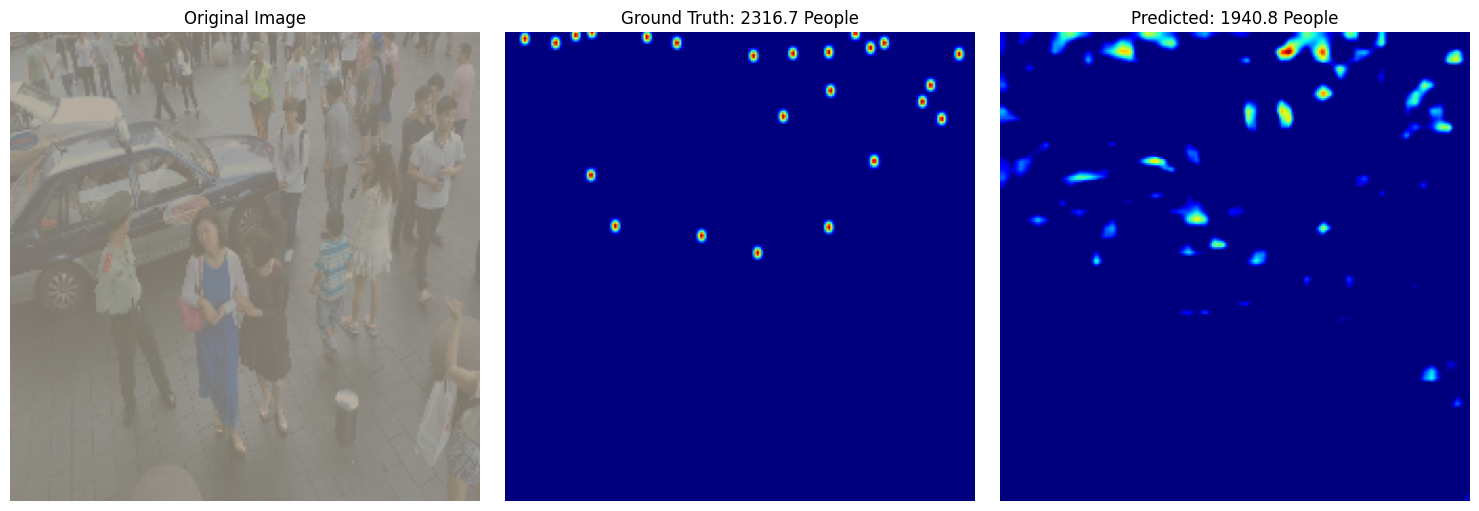

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


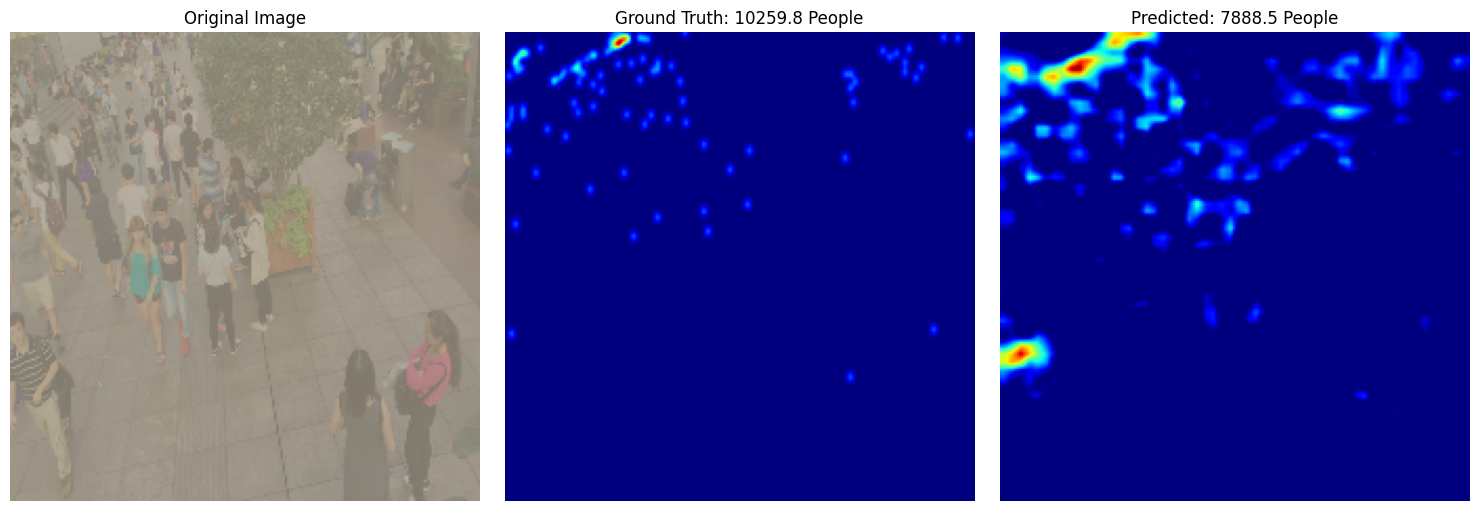

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


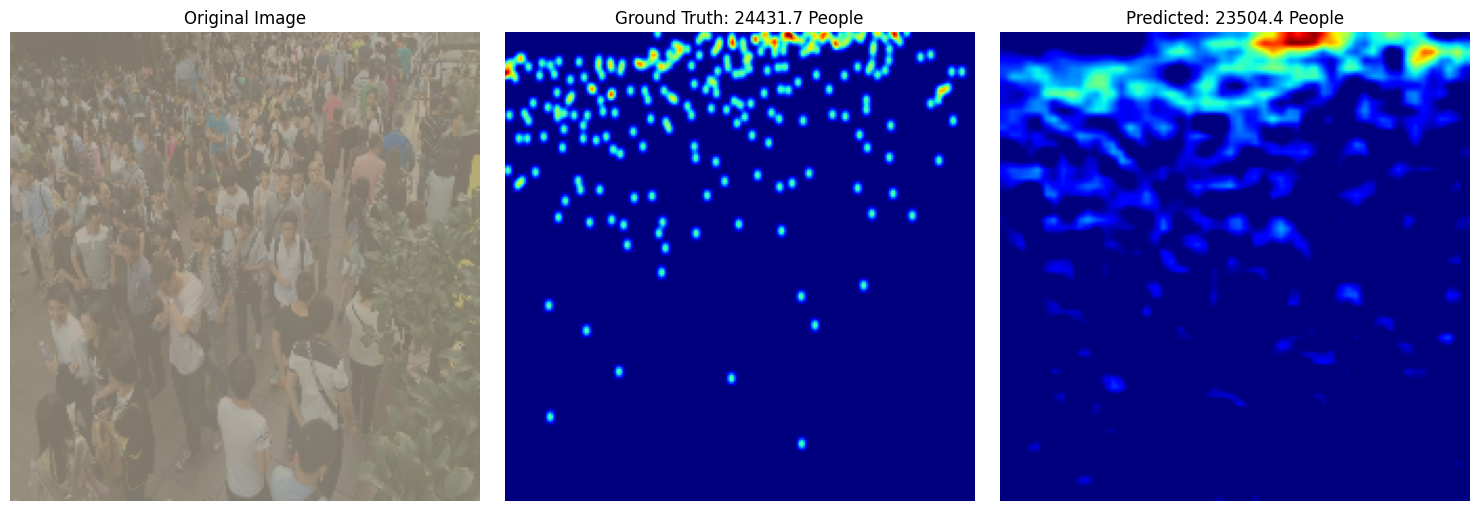

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Load best weights
model.load_weights("best_mcnn_model.h5")

image_dir = 'ShanghaiTech/part_B_final/test_data/images'
gt_dir = 'ShanghaiTech/part_B_final/test_data/ground_truth'

img_size = (224, 224)
scale_factor = 100.0
batch_size = 4

dataset_builder = ShanghaiCrowdDatasetTF(image_dir, gt_dir, img_size=img_size, scale_factor=scale_factor)
test_ds = dataset_builder.get_dataset(batch_size=batch_size, shuffle=True)

mae = 0.0
num_samples = 0

for batch in test_ds:
    image, gt_map = batch
    pred_map = model.predict(image)[0, :, :, 0]  # shape: (H, W)
    gt_map = gt_map[0, :, :, 0].numpy()

    # Count people
    pred_count = np.sum(pred_map)
    gt_count = np.sum(gt_map)
    mae += abs(pred_count - gt_count)
    num_samples += 1

    # --- Optional: Plot one result ---
    if num_samples <= 5:  # Plot first 5 samples
        img_np = image[0].numpy()
        img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]  # unnormalize
        img_np = np.clip(img_np, 0, 1)

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(img_np)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(gt_map, cmap='jet')
        plt.title(f"Ground Truth: {gt_count:.1f} People")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_map, cmap='jet')
        plt.title(f"Predicted: {pred_count:.1f} People")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

# Final MAE
print(f"Test MAE (Mean Absolute Error): {mae / num_samples:.2f}")
